## Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

## Load Dataset

In [3]:
df = pd.read_csv("../data/final_resume_dataset.csv")

print(df.shape)

df.head()

(3500, 8)


,ResumeID,Category,Skills,Education,Experience,Clean_Text,Text,Source
0,REAL_0001,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jared arthur maica java developer 17994568777 ...,jared arthur maica java developer linkedincomi...,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom montgo...,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
3,REAL_0004,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,jessica claire 9 resumesampleexamplecom montgo...,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
4,REAL_0005,Java Developer,"Python, SQL, Git, Linux",Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,jessica claire 100 montgomery st 10th floor xx...,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas


## Resume Character Length

In [4]:
df["Resume_Length"] = df["Clean_Text"].apply(len)

df["Resume_Length"].head()

0     1495
1     1686
2     5555
3    12834
4     4181
Name: Resume_Length, dtype: int64

## Resume Word Count

In [7]:
df["Word_Count"] = df["Clean_Text"].apply(lambda x: len(str(x).split()))

df["Word_Count"].head()

0     189
1     206
2     715
3    1657
4     489
Name: Word_Count, dtype: int64

## Sentence Count

In [8]:
df["Sentence_Count"] = df["Text"].apply(
    lambda x: len(str(x).split("."))
)

df["Sentence_Count"].head()

0    1
1    1
2    1
3    1
4    1
Name: Sentence_Count, dtype: int64

## Skill Count

In [10]:
df["Skill_Count"] = df["Skills"].apply(
    lambda x: len(str(x).split(","))
)

df["Skill_Count"].head()

0    4
1    4
2    4
3    4
4    4
Name: Skill_Count, dtype: int64

## Education Length

In [11]:
df["Education_Length"] = df["Education"].apply(
    lambda x: len(str(x).split())
)

df["Education_Length"].head()

0    3
1    3
2    3
3    3
4    3
Name: Education_Length, dtype: int64

## Experience Length

In [12]:
df["Experience_Length"] = df["Experience"].apply(
    lambda x: len(str(x).split())
)

df["Experience_Length"].head()

0    64
1    62
2    62
3    61
4    57
Name: Experience_Length, dtype: int64

## Source Encoding

In [14]:
source_encoder = LabelEncoder()

df["Source_Encoded"] = source_encoder.fit_transform(df["Source"])

df[["Source", "Source_Encoded"]].head()

,Source,Source_Encoded
0,ResumeAtlas,0
1,ResumeAtlas,0
2,ResumeAtlas,0
3,ResumeAtlas,0
4,ResumeAtlas,0


## Category Encoding

In [15]:
category_encoder = LabelEncoder()

df["Category_Encoded"] = category_encoder.fit_transform(df["Category"])

df[["Category","Category_Encoded"]].head()

,Category,Category_Encoded
0,Java Developer,17
1,Java Developer,17
2,Java Developer,17
3,Java Developer,17
4,Java Developer,17


## Dataset Information

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ResumeID           3500 non-null   object
 1   Category           3500 non-null   object
 2   Skills             3500 non-null   object
 3   Education          3500 non-null   object
 4   Experience         3500 non-null   object
 5   Clean_Text         3500 non-null   object
 6   Text               3500 non-null   object
 7   Source             3500 non-null   object
 8   Resume_Length      3500 non-null   int64 
 9   Word_Count         3500 non-null   int64 
 10  Sentence_Count     3500 non-null   int64 
 11  Skill_Count        3500 non-null   int64 
 12  Education_Length   3500 non-null   int64 
 13  Experience_Length  3500 non-null   int64 
 14  Source_Encoded     3500 non-null   int64 
 15  Category_Encoded   3500 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 437.6

## Statistical Summary

In [18]:
df.describe()

,Resume_Length,Word_Count,Sentence_Count,Skill_Count,Education_Length,Experience_Length,Source_Encoded,Category_Encoded
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,3303.470857,408.964286,3.042571,6.377143,6.106286,66.219429,0.332286,17.333143
std,3014.960625,363.054142,2.961343,3.499323,4.439954,15.416366,0.471100,9.999365
min,202.000000,26.000000,1.000000,4.000000,3.000000,28.000000,0.000000,0.000000
25%,1259.000000,173.000000,1.000000,4.000000,3.000000,57.000000,0.000000,8.000000
50%,2038.000000,248.000000,1.000000,4.000000,3.000000,61.000000,0.000000,17.000000
75%,4762.750000,569.000000,6.000000,12.000000,12.000000,68.000000,1.000000,26.000000
max,55923.000000,6498.000000,11.000000,12.000000,15.000000,118.000000,1.000000,35.000000


## Correlation Matrix

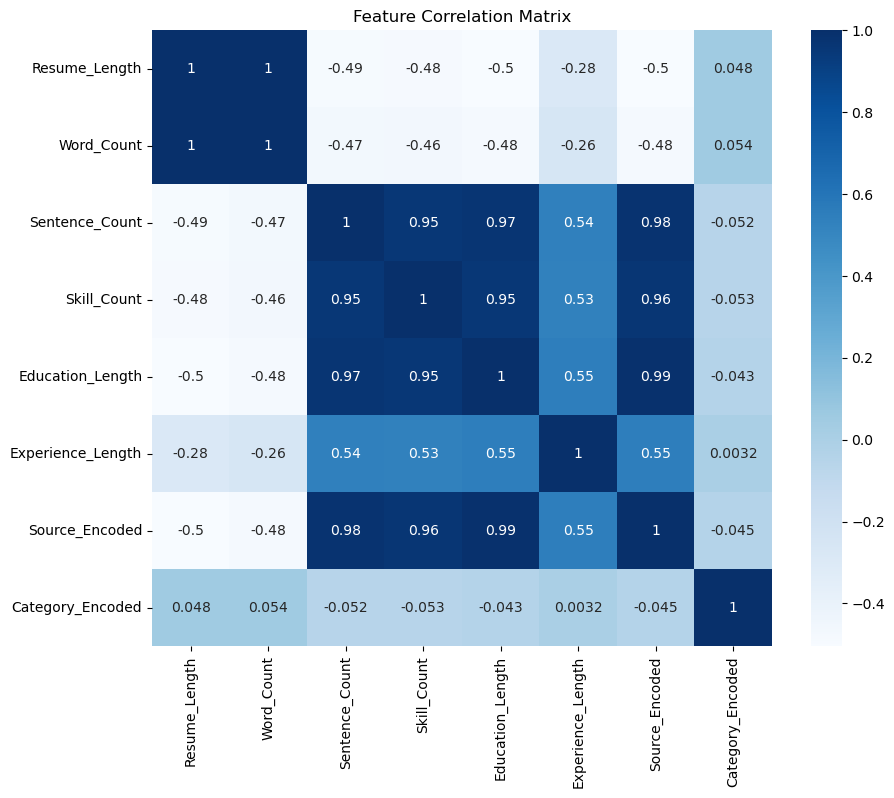

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Matrix")

plt.show()

## Save Feature Engineered Dataset

In [22]:
df.to_csv("../data/final_feature_dataset.csv", index=False)

print("Feature Engineered Dataset Saved Successfully")

Feature Engineered Dataset Saved Successfully


# Conclusion

✔ Created Resume_Length

✔ Created Word_Count

✔ Created Sentence_Count

✔ Created Skill_Count

✔ Created Experience_Length

✔ Created Education_Length

✔ Encoded Source

✔ Encoded Category

✔ Saved final feature dataset